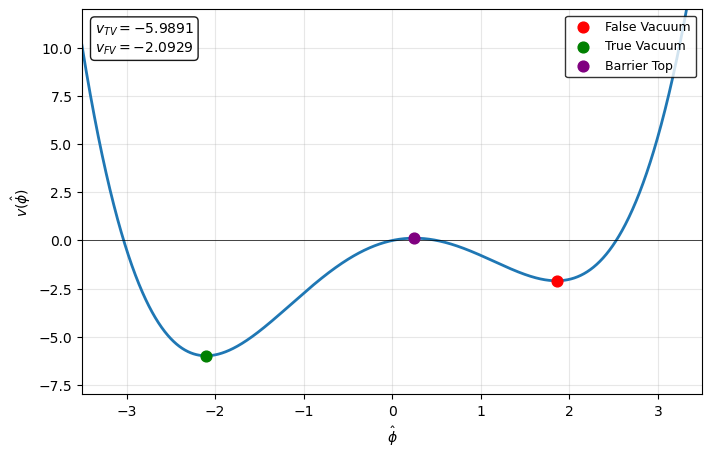


 n |   E_n (rescaled)   |   Lambda_n / H
---------------------------------------------
0 | -7.328028e-05 | -1.856211e-06
1 |  1.396925e-02 |  3.538453e-04
2 |  5.156140e+00 |  1.306066e-01
3 |  8.739815e+00 |  2.213821e-01
4 |  1.214467e+01 |  3.076280e-01


/tmp/ipykernel_220508/1532089333.py:225: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi)**2, phi_vals))
/tmp/ipykernel_220508/1532089333.py:244: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=9)


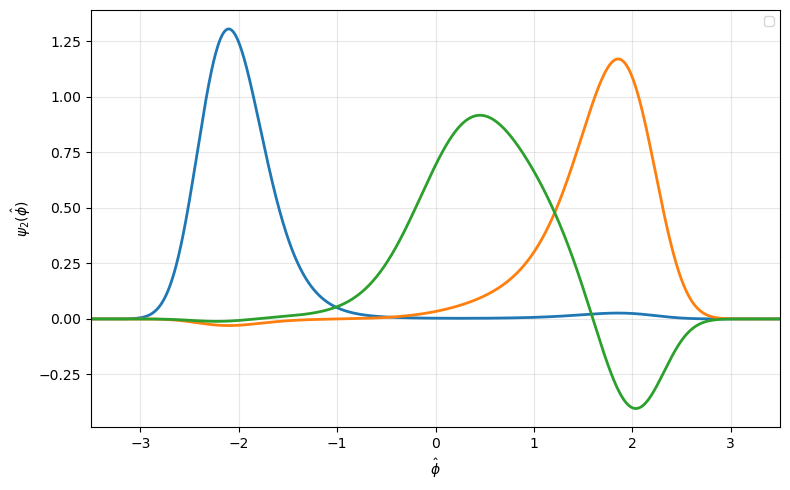

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.signal import find_peaks

# =========================
# TOGGLES
# =========================
SHOW_W = False   # True: show W(phi) inset, False: hide it

# Show/hide individual eigenfunctions
SHOW_PSI0 = True
SHOW_PSI1 = True
SHOW_PSI2 = True
SHOW_PSI3 = False
SHOW_PSI4 = False

# ----------------------------------------------------------------------
# 1) symbolic definitions
# ----------------------------------------------------------------------
phi, alpha, beta = sp.symbols('phi alpha beta', real=True)
Omega = 1 + alpha + sp.sqrt(beta)

v = (sp.pi**2 / (3 * Omega)) * (
    4*alpha*phi
    - 2*(beta/Omega)*phi**2
    + (4/Omega**3)*phi**4
)

v_prime = sp.diff(v, phi)
v_double_prime = sp.diff(v_prime, phi)
W = sp.Rational(1, 2) * (v_prime**2 - v_double_prime)

v_func = sp.lambdify((phi, alpha, beta), v, 'numpy')
W_func = sp.lambdify((phi, alpha, beta), W, 'numpy')

# ----------------------------------------------------------------------
# 2) parameters
# ----------------------------------------------------------------------
alpha_val = 0.2
beta_val = 2.2
lambda_val = 0.05

Omega_val = 1 + alpha_val + np.sqrt(beta_val)
scale = np.sqrt(lambda_val) * Omega_val**2

# grid
N = 4001
L_solve = 8.0
phi_vals = np.linspace(-L_solve, L_solve, N)
dphi = phi_vals[1] - phi_vals[0]

# ----------------------------------------------------------------------
# 3) compute potentials
# ----------------------------------------------------------------------
v_vals = v_func(phi_vals, alpha_val, beta_val)
if SHOW_W:
    W_vals_inset = W_func(phi_vals, alpha_val, beta_val)

# ---- find minima (vacua) in v ----
min_idx, _ = find_peaks(-v_vals)
min_phi = phi_vals[min_idx]
min_v = v_vals[min_idx]

order = np.argsort(min_v)
true_phi, false_phi = min_phi[order[0]], min_phi[order[1]]
true_v, false_v = min_v[order[0]], min_v[order[1]]

# ---- find barrier (max between vacua) in v ----
mask_v = (phi_vals > min(true_phi, false_phi)) & (phi_vals < max(true_phi, false_phi))
barrier_idx, _ = find_peaks(v_vals[mask_v])

bar_phi = phi_vals[mask_v][barrier_idx]
bar_v = v_vals[mask_v][barrier_idx]
imax = np.argmax(bar_v)
bar_phi, bar_v = bar_phi[imax], bar_v[imax]

# ----------------------------------------------------------------------
# 4) main plot: v(phi) + optional inset: W(phi)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(phi_vals, v_vals, lw=2)
ax.scatter(false_phi, false_v, color='red', s=60, zorder=5, label='False Vacuum')
ax.scatter(true_phi,  true_v,  color='green', s=60, zorder=5, label='True Vacuum')
ax.scatter(bar_phi,   bar_v,   color='purple', s=60, zorder=5, label='Barrier Top')
ax.axhline(0, color='black', lw=0.5)

ax.set_xlabel(r'$\hat{\phi}$')
ax.set_ylabel(r'$v(\hat{\phi})$')

ax.legend(
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='black',
    fontsize=9
)

info_text = (
    rf"$v_{{TV}} = {true_v:.4f}$" "\n"
    rf"$v_{{FV}} = {false_v:.4f}$"
)

ax.text(
    0.02, 0.97,
    info_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black')
)

# -----------------------------
# OPTIONAL inset: W(phi)
# -----------------------------
if SHOW_W:
    axins = ax.inset_axes([0.48, 0.642, 0.40, 0.35])

    axins.plot(phi_vals, W_vals_inset, lw=1.6)
    axins.axhline(0, color='black', lw=0.4)
    axins.set_facecolor('whitesmoke')
    axins.tick_params(labelsize=8)

    axins.text(
        0.5, 0.95, r"$W(\phi)$",
        transform=axins.transAxes,
        ha='center', va='top',
        fontsize=9, fontweight='bold'
    )

    axins.set_xlim(-5, 5)
    axins.set_ylim(-15, 18)

    min_idx_W, _ = find_peaks(-W_vals_inset)
    if len(min_idx_W) < 2:
        raise RuntimeError("Could not find two minima of W(phi) on this phi range.")

    min_phi_W = phi_vals[min_idx_W]
    min_W = W_vals_inset[min_idx_W]

    orderW = np.argsort(min_W)
    true_phi_W, false_phi_W = min_phi_W[orderW[0]], min_phi_W[orderW[1]]
    true_W, false_W = min_W[orderW[0]], min_W[orderW[1]]

    axins.scatter(true_phi_W,  true_W,  marker='*', s=40, color='black', zorder=6)
    axins.scatter(false_phi_W, false_W, marker='o', s=25, color='black', zorder=6)

    textstr_W = (
        rf"$\star\; W_{{TV}} = {true_W:.3f}$" "\n"
        rf"$\bullet\; W_{{FV}} = {false_W:.3f}$"
    )

    axins.text(
        0.03, 0.96,
        textstr_W,
        transform=axins.transAxes,
        fontsize=8,
        va='top',
        bbox=dict(boxstyle="square", facecolor="white", alpha=0.9)
    )

    axins.set_xlim(-4, 4)
    axins.set_ylim(-7, 18)

# zoom main v plot
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-8, 12)
ax.grid(True, alpha=0.3)


plt.show()

# ----------------------------------------------------------------------
# 5) build W and solve spectrum
# ----------------------------------------------------------------------
W_vals = W_func(phi_vals, alpha_val, beta_val)

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags(
    [off_diag, main_diag, off_diag],
    [-1, 0, 1],
    format='csr'
) / dphi**2

T = -0.5 * laplacian
V = diags(W_vals, 0)

H_op = scale * (T + V)

num_eigs = 5
E_vals, E_vecs = eigsh(H_op, k=num_eigs, sigma=0.0, which='LM')

# sort eigenvalues and eigenvectors together
idx = np.argsort(E_vals)
E_vals = E_vals[idx]
E_vecs = E_vecs[:, idx]

Lambda_over_H = E_vals / (4 * np.pi**2)

print("\n n |   E_n (rescaled)   |   Lambda_n / H")
print("-" * 45)
for n in range(num_eigs):
    print(f"{n:1d} | {E_vals[n]: .6e} | {Lambda_over_H[n]: .6e}")

# ----------------------------------------------------------------------
# 6) plot selected eigenfunctions
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))

show_flags = [SHOW_PSI0, SHOW_PSI1, SHOW_PSI2, SHOW_PSI3, SHOW_PSI4]

for n in range(num_eigs):
    if not show_flags[n]:
        continue

    psi = E_vecs[:, n]

    # normalize: integral |psi|^2 dphi = 1
    norm = np.sqrt(np.trapz(np.abs(psi)**2, phi_vals))
    psi = psi / norm

    # optional sign flip for nicer display
    if psi[np.argmax(np.abs(psi))] < 0:
        psi = -psi

    ax2.plot(
        phi_vals,
        psi,
        lw=2,
        
    )

ax2.set_xlabel(r'$\hat{\phi}$')
ax2.set_ylabel(r'$\psi_2(\hat{\phi})$')
#ax2.set_title("Selected eigenfunctions")
ax2.set_xlim(-3.5, 3.5)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("psi2", dpi=300, bbox_inches="tight")
plt.show()